# Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Import Modules
### ★ Import all the modules needed for deep learning (TensorFlow, Keras), data manipulation, plotting and image processing

In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

import os
import random
import matplotlib.image as mpimg
import cv2
import shutil

import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing import image
from tqdm import tqdm
from tensorflow.keras.regularizers import l2
from sklearn.metrics import classification_report , confusion_matrix

from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.applications import MobileNetV2

warnings.filterwarnings('ignore')

# Load Dataset Labels (in CSV file)

### ★ Loads the labels.csv file into a pandas DataFrame named 'df'

In [ ]:
path='/content/drive/MyDrive/Eye_Prediction_Model/labels_validity.csv'
df=pd.read_csv(path)
df.head()

,name,validity
0,1.jpg,eye
1,2.jpg,eye
2,3.jpg,eye
3,4.jpg,eye
4,5.jpg,eye


# Display Sample of Data Images with Labels 

### ★ Displays a sample of original images with their labels for initial inspection.

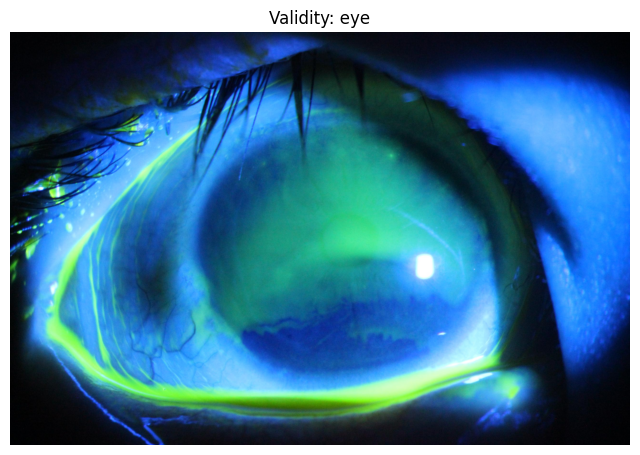

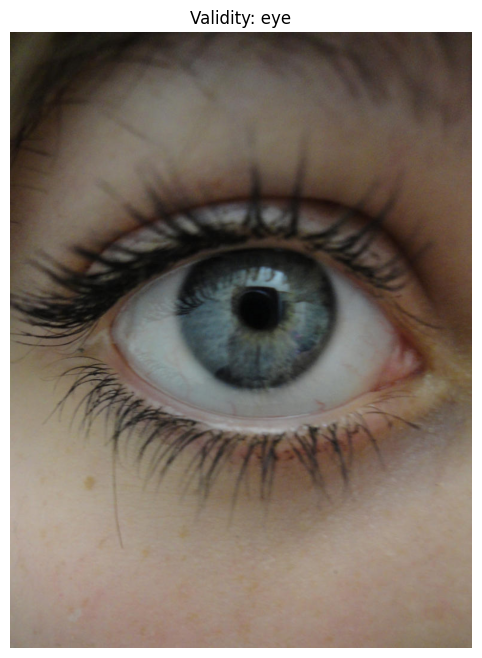

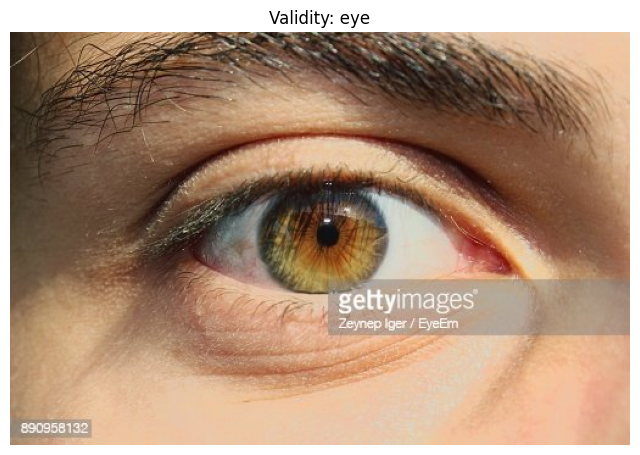

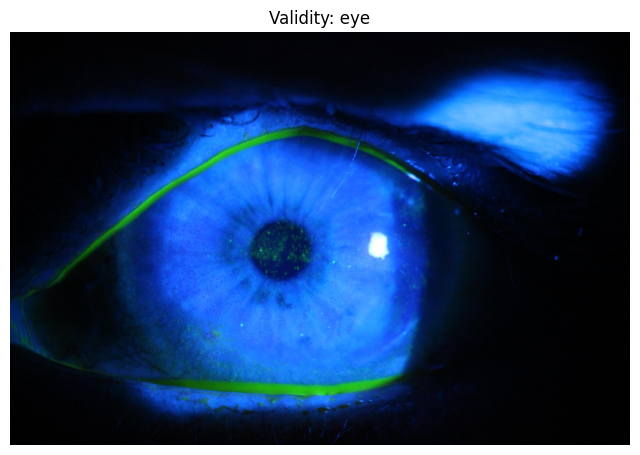

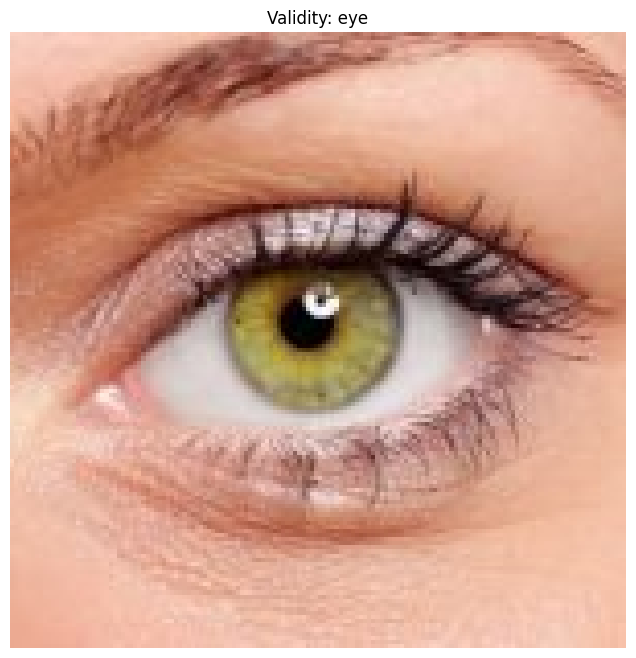

In [ ]:
# Directory containing images
image_dir = "/content/drive/MyDrive/GroupMitchell/dataset_validity/images"

# Load dataset
csv_file_path = "/content/drive/MyDrive/GroupMitchell/labels_validity.csv"
dataset = pd.read_csv(csv_file_path)

# Select five random images
random_image_indices = random.sample(range(len(dataset)), 5)

# Display the selected images with labels
for idx in random_image_indices:
    image_path = os.path.join(image_dir, dataset.loc[idx, 'name'])
    image = mpimg.imread(image_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.title(f"Validity: {dataset.loc[idx, 'validity']}")
    plt.axis('off')
    plt.show()

# Create Dictionaries 

### ★ Creates dictionaries to store counts of unique eye and non-eye

In [ ]:
Type_of_validity=df['validity'].unique()
Type_of_validity

# Creates dictionaries to store counts of unique eye and non-eye
dic={}
for i in Type_of_validity:
    dic[i]=df['validity'].value_counts()[i]

print(dic)

{'eye': np.int64(460), 'non-eye': np.int64(172)}


# Generate Bar Plots

### ★ Generates bar plots to visualize the distribution of eye and non-eye images

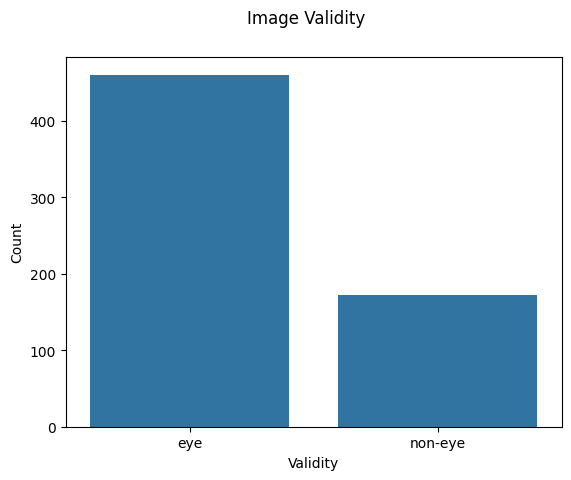

In [ ]:
sns.barplot(x = list(dic.keys()), y = list(dic.values()))
plt.suptitle("Image Validity")
plt.xlabel("Validity")
plt.ylabel("Count")
plt.show()

# Dataset Splitting 

### ★ Split the dataset into training and testing sets using 80:20 ratio and create two folders consisting the splitted 'Training' and 'Testing' images

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
import os
import shutil

# Source folder for all original images
source_original_image_folder = "/content/drive/MyDrive/GroupMitchell/dataset_validity/images"

# Define new destination directories for original images after split
original_training_images_folder = "/content/drive/MyDrive/GroupMitchell/validity_training_images"
original_testing_images_folder = "/content/drive/MyDrive/GroupMitchell/validity_testing_images"

# Create destination folders if they don't exist
os.makedirs(original_training_images_folder, exist_ok=True)
os.makedirs(original_testing_images_folder, exist_ok=True)

print(f"Original df shape: {df.shape}")

# Prepare target data for splitting and include image names from the filtered DataFrame
y_validity_original = df['validity'].values
image_names_original = df['name'].values

# Perform the initial 80:20 split on the full original dataset (including image names)
# We will split based on 'validity' and 'image_names_original'
(
    train_validity_labels, test_validity_labels,
    train_image_names_original, test_image_names_original
) = train_test_split(
    y_validity_original, image_names_original,
    test_size=0.2,
    random_state=42,
    stratify=y_validity_original  # Stratify to maintain class distribution
)

print(f"\nTotal original training images: {len(train_image_names_original)}")
print(f"Total original testing images: {len(test_image_names_original)}")

# Create DataFrames for original training and testing labels
train_df_original = df[df['name'].isin(train_image_names_original)].reset_index(drop=True)
test_df_original = df[df['name'].isin(test_image_names_original)].reset_index(drop=True)

print("\nCopying original training images...")
for image_name in train_image_names_original:
    src_path = os.path.join(source_original_image_folder, image_name)
    dst_path = os.path.join(original_training_images_folder, image_name)
    if os.path.exists(src_path):
        shutil.copy(src_path, dst_path) # Use copy to keep original dataset intact
    else:
        print(f"Warning: Original training image {image_name} not found at {src_path}")

print("\nCopying original testing images...")
for image_name in test_image_names_original:
    src_path = os.path.join(source_original_image_folder, image_name)
    dst_path = os.path.join(original_testing_images_folder, image_name)
    if os.path.exists(src_path):
        shutil.copy(src_path, dst_path) # Use copy to keep original dataset intact
    else:
        print(f"Warning: Original testing image {image_name} not found at {src_path}")

print("\nOriginal images organized into training and testing folders. Check your Google Drive for the new folders.")

print("\nOriginal Training DataFrame head:")
display(train_df_original.head())
print("\nOriginal Testing DataFrame head:")
display(test_df_original.head())

Original df shape: (632, 2)

Total original training images: 505
Total original testing images: 127

Copying original training images...

Copying original testing images...

Original images organized into training and testing folders. Check your Google Drive for the new folders.

Original Training DataFrame head:


,name,validity
0,1.jpg,eye
1,3.jpg,eye
2,4.jpg,eye
3,5.jpg,eye
4,6.jpg,eye



Original Testing DataFrame head:


,name,validity
0,2.jpg,eye
1,14.jpg,eye
2,21.jpg,eye
3,22.jpg,eye
4,35.jpg,eye


# Data Augmentation

### ★ The training images undergo augmentation techniques such as slight rotation and brightness adjustment
### ★ The augmented training images is saved into another new folder that is automatically created

In [ ]:
import cv2
import os
import pandas as pd
import numpy as np
import random

# ° \u1923\u1929 . ° . Function to augment images ° \u1923\u1929 . ° .
def augment_image(image_path):
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error loading image for augmentation: {image_path}")
        return []

    # Convert image to float32 for lighting adjustments
    image = image.astype(np.float32)

    augmented_images = []

    # Augmentation 1: Slight Rotation
    angle = random.uniform(-15, 15) # Rotate between -15 and 15 degrees
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated_image = cv2.warpAffine(image, M, (w, h), borderMode=cv2.BORDER_REFLECT)
    augmented_images.append(rotated_image)

    # Augmentation 2: Different Lighting (Brightness and Contrast)
    # Randomly adjust brightness and contrast
    alpha = random.uniform(0.8, 1.2)  # Contrast factor
    beta = random.uniform(-30, 30)    # Brightness factor
    light_adjusted_image = cv2.convertScaleAbs(image, alpha=alpha, beta=beta)
    augmented_images.append(light_adjusted_image)

    # Augmentation 3: Combine slight rotation and different lighting
    angle_combined = random.uniform(-15, 15)
    alpha_combined = random.uniform(0.8, 1.2)
    beta_combined = random.uniform(-30, 30)

    M_combined = cv2.getRotationMatrix2D(center, angle_combined, 1.0)
    rotated_then_adjusted_image = cv2.warpAffine(image, M_combined, (w, h), borderMode=cv2.BORDER_REFLECT)
    rotated_then_adjusted_image = cv2.convertScaleAbs(rotated_then_adjusted_image, alpha=alpha_combined, beta=beta_combined)
    augmented_images.append(rotated_then_adjusted_image)

    return augmented_images

# Define output folder for augmented training images
augmented_training_images_folder = "/content/drive/MyDrive/GroupMitchell/augmented_validity_training_images"

# Create output folder if not exists
if not os.path.exists(augmented_training_images_folder):
    os.makedirs(augmented_training_images_folder)

# Augment training images and collect their labels
augmented_train_data = []
print("\nAugmenting training images...")
for index, row in train_df_original.iterrows():
    image_name = row['name']
    image_path = os.path.join(original_training_images_folder, image_name)

    # Get the augmented images
    augmented_versions = augment_image(image_path)

    for i, augmented_img_data in enumerate(augmented_versions, start=1):
        augmented_image_name = f"augmented_train_{index}_{i}_{image_name}" # Unique name including original name
        augmented_image_path = os.path.join(augmented_training_images_folder, augmented_image_name)
        cv2.imwrite(augmented_image_path, augmented_img_data)
        augmented_row = {
            'name': augmented_image_name,
            'validity': row['validity'] # Use the 'validity' column
        }
        augmented_train_data.append(augmented_row)

augmented_train_df = pd.DataFrame(augmented_train_data)

print(f"Augmented training images created: {len(augmented_train_df)}")
print("Augmented Training DataFrame head:")
display(augmented_train_df.head())


Augmenting training images...
Augmented training images created: 1515
Augmented Training DataFrame head:


,name,validity
0,augmented_train_0_1_1.jpg,eye
1,augmented_train_0_2_1.jpg,eye
2,augmented_train_0_3_1.jpg,eye
3,augmented_train_1_1_3.jpg,eye
4,augmented_train_1_2_3.jpg,eye


# Combine original training images and augmented training images

### ★ The original training images and augmented training images is combined into 'Final Training Set' for Training

In [ ]:
# Combine original and augmented training data for the final training set
final_train_df = pd.concat([train_df_original, augmented_train_df], ignore_index=True)

# The testing set remains as the original testing data
final_test_df = test_df_original

# Combine final training and testing data for the overall dataset `df`
df = pd.concat([final_train_df, final_test_df], ignore_index=True)

# Save the new combined dataset to CSV
combined_dataset_new_workflow_path = "/content/drive/MyDrive/GroupMitchell/combined_dataset_validity.csv"
df.to_csv(combined_dataset_new_workflow_path, index=False)
print(f"New combined dataset saved to: {combined_dataset_new_workflow_path}")
print(f"Final 'df' for model building has {len(df)} rows.")

# Create a mapping from image name to its full path for efficient loading
image_name_to_path_map = {}

# Add paths for original training images
for name in train_df_original['name']:
    image_name_to_path_map[name] = os.path.join(original_training_images_folder, name)

# Add paths for augmented training images
for name in augmented_train_df['name']:
    image_name_to_path_map[name] = os.path.join(augmented_training_images_folder, name)

# Add paths for original testing images
for name in test_df_original['name']:
    image_name_to_path_map[name] = os.path.join(original_testing_images_folder, name)

print("Image name to path map created. Ready for image loading into X.")
display(df.head())

New combined dataset saved to: /content/drive/MyDrive/GroupMitchell/combined_dataset_validity.csv
Final 'df' for model building has 2147 rows.
Image name to path map created. Ready for image loading into X.


,name,validity
0,1.jpg,eye
1,3.jpg,eye
2,4.jpg,eye
3,5.jpg,eye
4,6.jpg,eye


# Loads 'Final Training Set' labels

### ★ Loads the combined_dataset_validity.csv labels for training

In [ ]:
import os

# Path to the combined_dataset.csv file
combined_dataset_path = "/content/drive/MyDrive/GroupMitchell/combined_dataset_validity.csv"

# Check if the file exists
if os.path.exists(combined_dataset_path):
    print(f"The file '{combined_dataset_path}' exists.")
else:
    print(f"The file '{combined_dataset_path}' does NOT exist.")

The file '/content/drive/MyDrive/GroupMitchell/combined_dataset_validity.csv' exists.


In [ ]:
combined_dataset = pd.read_csv(combined_dataset_path)
print(f"Loaded {len(combined_dataset)} rows from combined_dataset_validity.csv")

Loaded 2147 rows from combined_dataset_validity.csv


In [ ]:
# Assigns the combined dataset (original + augmented) to the main DataFrame 'df'.
df=combined_dataset
df

,name,validity
0,1.jpg,eye
1,3.jpg,eye
2,4.jpg,eye
3,5.jpg,eye
4,6.jpg,eye
...,...,...
2142,neg_00160.jpg,non-eye
2143,neg_00161.jpg,non-eye
2144,neg_00162.jpg,non-eye
2145,neg_00168.jpg,non-eye


# Model Training

### ★ 1. Loads and preprocesses all images (original and augmented) into NumPy array 'X'

In [ ]:
# Loads and preprocesses all images (original and augmented) into a NumPy array 'X'.
from tensorflow.keras.preprocessing import image

train_images = []

# The image_name_to_path_map is created in cell 9f443b0b after data augmentation and splitting.
# It contains the correct path for each image based on its type (original_train, augmented_train, original_test).

# Loop through the 'df' DataFrame (which now contains all combined image names) and load images
for i in tqdm(range(df.shape[0])):
    image_name = df['name'][i]

    # Get the correct image path from the map
    if image_name in image_name_to_path_map:
        image_path = image_name_to_path_map[image_name]
    else:
        # Fallback for any image names not found in the map (should not happen if previous steps ran correctly)
        print(f"Warning: Image {image_name} not found in path map. Attempting to load from a default folder.")
        # You might want to define a default folder or handle this error more robustly
        image_path = os.path.join("/content/drive/MyDrive/GroupMitchell/dataset_validity/images", image_name) # Example fallback

    img = image.load_img(image_path, target_size=(224, 224))
    img = image.img_to_array(img)
    img = img/255
    train_images.append(img)

X = np.array(train_images)
print(f"Loaded {X.shape[0]} images with shape {X.shape[1:]}")


100%|██████████| 2147/2147 [00:50<00:00, 42.24it/s]


Loaded 2147 images with shape (224, 224, 3)



### ★ 2. Calculate number of unique classes for each target output

In [ ]:
# Get the number of unique classes for each target
num_validity = df['validity'].nunique()

print(f"Number of validity: {num_validity}")

Number of validity: 2


### ★ 3. Defines and compiles the single-output MobileNetV2 model for validity

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
import os
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Clear any previous TensorFlow session state
tf.keras.backend.clear_session()

# Define the weights path for MobileNetV2 (using absolute path)
weights_path = '/content/drive/MyDrive/GroupMitchell/dataset/mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_224_no_top.h5'

# Check if the weights file exists. If not, MobileNetV2 will initialize with random weights.
if not os.path.exists(weights_path):
    print(f"Warning: MobileNetV2 weights file not found at {weights_path}. Initializing with random weights.")
    base_weights = None
else:
    base_weights = weights_path

# Load MobileNetV2 base model
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights=base_weights)

# Freeze layers in the base model
for layer in base_model.layers:
    layer.trainable = False

# Create a LabelEncoder for 'validity' labels
le = LabelEncoder()
df['validity_encoded'] = le.fit_transform(df['validity'])

# Get the number of unique validity classes after encoding
num_validity_classes = df['validity_encoded'].nunique()
print(f"Number of unique validity classes: {num_validity_classes}")

# Add custom head for validity classification
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
dropout = Dropout(0.3)(x)
output_validity = Dense(num_validity_classes, activation='softmax', name='validity_output')(dropout)

# Create the single-output model
single_output_model = Model(inputs=base_model.input, outputs=[output_validity])

# Compile the model with appropriate loss and metrics
losses = {'validity_output': 'sparse_categorical_crossentropy'}
metrics = {'validity_output': 'accuracy'}

single_output_model.compile(optimizer='adam', loss=losses, metrics=metrics)

# Display model summary
single_output_model.summary()


Number of unique validity classes: 2


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### ★ 4. Prepare target data for splitting using the encoded 'validity' labels

In [ ]:
import numpy as np

# Prepare target data for splitting using the encoded 'validity' labels
y_validity_encoded = df['validity_encoded'].values

# Determine the split point based on the length of the final training DataFrame
# This assumes df was created by pd.concat([final_train_df, final_test_df], ignore_index=True)
# and X was loaded in the same order.
num_train_samples = len(final_train_df)

# Split X and target arrays manually based on the pre-defined split
X_train = X[:num_train_samples]
X_test = X[num_train_samples:]

y_train_validity = y_validity_encoded[:num_train_samples]
y_test_validity = y_validity_encoded[num_train_samples:]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train_validity shape: {y_train_validity.shape}")
print(f"y_test_validity shape: {y_test_validity.shape}")

# Combine training and testing targets into dictionaries for model.fit
y_train_targets = {
    'validity_output': y_train_validity
}

y_test_targets = {
    'validity_output': y_test_validity
}

X_train shape: (2020, 224, 224, 3)
X_test shape: (127, 224, 224, 3)
y_train_validity shape: (2020,)
y_test_validity shape: (127,)


### ★ 5. Trains the single-output model

In [ ]:
# Train the single-output model
history = single_output_model.fit(
    X_train,
    y_train_validity,
    epochs=10,  # You can adjust the number of epochs
    batch_size=32,
    validation_data=(X_test, y_test_validity),
    verbose=1
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.9649 - loss: 0.0973 - val_accuracy: 1.0000 - val_loss: 0.0017
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 0.0020
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 1.0000 - loss: 4.5446e-04 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.9995 - loss: 7.2807e-04 - val_accuracy: 1.0000 - val_loss: 9.0246e-04
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 1.0000 - loss: 1.9427e-04 - val_accuracy: 1.0000 - val_loss: 8.7597e-04
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 1.0000 - loss: 1.5446e-04 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 1.0000 - loss: 1.0475e-04 - val_accuracy: 1.0000 - val_loss: 8.4795e-04
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 1.0000 - loss: 8.634

# Model Performance Evaluation

### ★ Display the Final Training and Testing Metrics

In [ ]:
train_validity_accuracy = history.history['accuracy']
val_validity_accuracy = history.history['val_accuracy']

train_validity_loss = history.history['loss']
val_validity_loss = history.history['val_loss']

print("\n--- Final Training and Testing Metrics ---")

print("\nValidity Output:")
print(f"  Training Accuracy: {train_validity_accuracy[-1]:.4f}")
print(f"  Testing Accuracy: {val_validity_accuracy[-1]:.4f}")
print(f"  Training Loss: {train_validity_loss[-1]:.4f}")
print(f"  Testing Loss: {val_validity_loss[-1]:.4f}")


--- Final Training and Testing Metrics ---

Validity Output:
  Training Accuracy: 1.0000
  Testing Accuracy: 1.0000
  Training Loss: 0.0000
  Testing Loss: 0.0009


# Save the Keras and .h5 Model

### ★ The models are saved for deployment

In [ ]:
# Needed: Saves the weights of the single-output model.
# Save the weights of the single-output model
single_output_model.save_weights('/content/drive/MyDrive/GroupMitchell/single_output_model.weights.h5')
print("Single-output model weights saved to 'single_output_model.weights.h5'")

Single-output model weights saved to 'single_output_model2.weights.h5'


In [ ]:
import os

# Define the path to save the entire Keras model file
model_save_path = '/content/drive/MyDrive/GroupMitchell/single_output_model.keras'

# Save the entire model (architecture, weights, and optimizer state)
single_output_model.save(model_save_path)

print(f"Entire Keras model saved to '{model_save_path}'")

# Verify that the file exists
if os.path.exists(model_save_path):
    print("Model file successfully created.")
else:
    print("Error: Model file was not created.")

Entire Keras model saved to '/content/drive/MyDrive/GroupMitchell/single_output_model.keras'
Model file successfully created.


# Model Prediction

### ★ Make prediction based on input image

Processing images from: /content/drive/MyDrive/GroupMitchell/predict_images

Predicting on image: eye_1.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


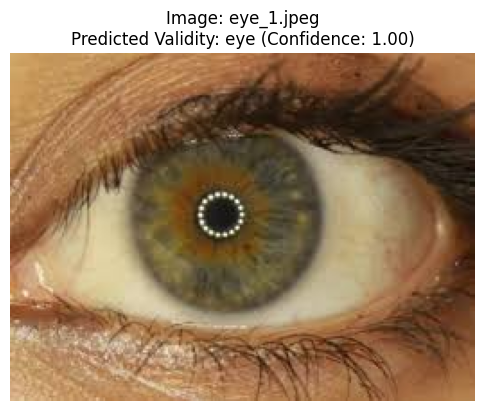


--------------------------------------------------

Predicting on image: noneye_1.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


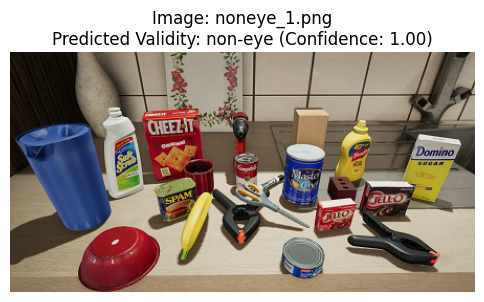


--------------------------------------------------

Predicting on image: eye_3.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


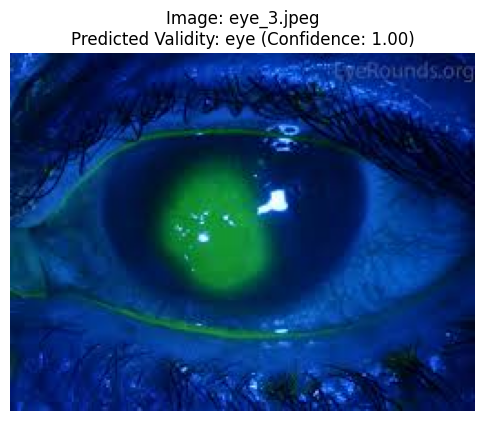


--------------------------------------------------

Predicting on image: noneye_2.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


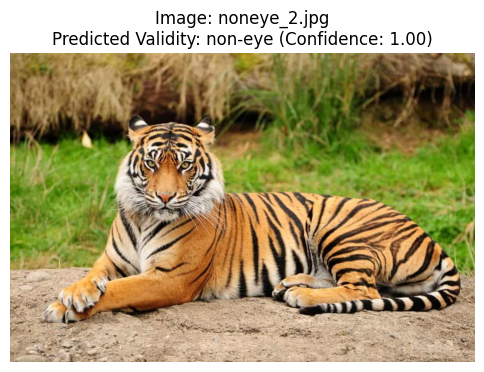


--------------------------------------------------

Predicting on image: eye_new2.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


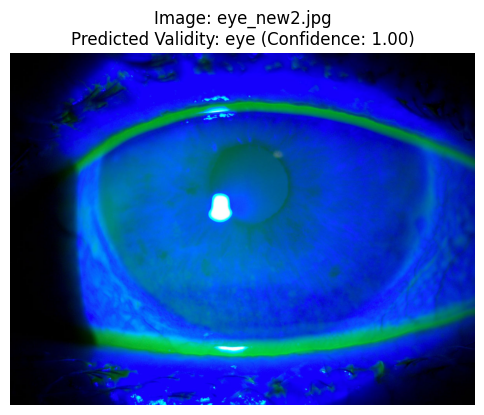


--------------------------------------------------



In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import os

# Function to preprocess an image for prediction
def preprocess_image(img_path, target_size=(224, 224)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = img_array / 255.0  # Normalize to [0, 1]
    return img_array

# --- Predict on new images from a specific folder ---
# Define the path to your folder containing new images for prediction
new_images_folder = "/content/drive/MyDrive/GroupMitchell/predict_images" # <--- **CHANGE THIS TO YOUR FOLDER PATH**

if not os.path.exists(new_images_folder):
    print(f"Error: The folder '{new_images_folder}' does not exist. Please create it and add images, or update the path.")
else:
    print(f"Processing images from: {new_images_folder}\n")

    image_files = [f for f in os.listdir(new_images_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]

    if not image_files:
        print(f"No image files found in '{new_images_folder}'. Please ensure there are images in the folder.")
    else:
        for image_name in image_files:
            sample_image_path = os.path.join(new_images_folder, image_name)

            print(f"Predicting on image: {image_name}")

            # Preprocess the image
            processed_image = preprocess_image(sample_image_path)

            # Make a prediction using the trained model
            predictions = single_output_model.predict(processed_image)

            # The output is a probability distribution over the classes
            # predictions will be a 2D array, e.g., [[prob_class_0, prob_class_1]]
            validity_probabilities = predictions[0] # Get the first (and only) row of predictions

            # Get the predicted class index (highest probability)
            predicted_class_index = np.argmax(validity_probabilities)

            # Decode the predicted class index back to the original label using the LabelEncoder
            if 'le' not in globals():
                print("Error: LabelEncoder 'le' not found. Please run the model definition cell first.")
                predicted_validity_label = f"Class Index: {predicted_class_index}" # Fallback if encoder not found
            else:
                predicted_validity_label = le.inverse_transform([predicted_class_index])[0]

            # Display the image and its predicted label
            plt.figure(figsize=(6, 6))
            img_to_display = image.load_img(sample_image_path)
            plt.imshow(img_to_display)
            # Access the confidence correctly from the 1D array validity_probabilities
            plt.title(f"Image: {image_name}\nPredicted Validity: {predicted_validity_label} (Confidence: {validity_probabilities[predicted_class_index]:.2f})")
            plt.axis('off')
            plt.show()
            print("\n" + "-"*50 + "\n")